# Task 5 — First live connection (pandas + matplotlib)
Place `DWBI_W1_Regional_Sales.xlsx` next to this notebook and run all cells. The report page is saved as `task5_report.png`.

## Before loading
1. **Which column tells us what product was sold?** `Sales.ProductID` (a code); the readable name is in `Products.ProductName`.
2. **Where does the region's name live?** `Regions.RegionName`; `Sales` holds only `RegionID`.
3. **Slicer on Product Category — which table?** `Products.Category`. `Sales` has no Category column; category is stored once per product, and filtering through the Products relationship reaches the matching Sales rows.

## Connect

In [3]:
import pandas as pd, hashlib, matplotlib.pyplot as plt
F = "DWBI_W1_Regional_Sales.xlsx"
sha = lambda p: hashlib.sha256(open(p,"rb").read()).hexdigest()
hash_before = sha(F)
sales = pd.read_excel(F, sheet_name="Sales")
prod  = pd.read_excel(F, sheet_name="Products")
reg   = pd.read_excel(F, sheet_name="Regions")
# If a sheet loads with the wrong header row, fix it here (e.g. header=1), never in the file.
print(len(sales), len(prod), len(reg), "(expected 480 / 15 / 4)")
print(sales.columns.tolist(), prod.columns.tolist(), reg.columns.tolist())

480 15 4 (expected 480 / 15 / 4)
['SaleID', 'SaleDate', 'ProductID', 'RegionID', 'Quantity', 'UnitPrice', 'SalesAmount'] ['ProductID', 'ProductName', 'Category', 'UnitPrice'] ['RegionID', 'RegionName', 'HeadOffice', 'RegionalManager']


## Check the relationships

In [4]:
for name, dim, key in [("Products", prod, "ProductID"), ("Regions", reg, "RegionID")]:
    print(f"{name}[{key}] unique: {dim[key].is_unique} ({len(dim)} rows) | "
          f"Sales[{key}] repeats: {sales[key].duplicated().any()} | "
          f"orphans in Sales: {(~sales[key].isin(dim[key])).sum()}")
# validate= raises an error if the join is not many-to-one
data = (sales.merge(prod[["ProductID","ProductName","Category"]], on="ProductID", how="left", validate="many_to_one")
             .merge(reg[["RegionID","RegionName"]], on="RegionID", how="left", validate="many_to_one"))
print("Rows after joins:", len(data), "(must stay 480)")

Products[ProductID] unique: True (15 rows) | Sales[ProductID] repeats: True | orphans in Sales: 0
Regions[RegionID] unique: True (4 rows) | Sales[RegionID] repeats: True | orphans in Sales: 0
Rows after joins: 480 (must stay 480)


- **Products[ProductID] → Sales[ProductID]:** one side = Products, many side = Sales. Shown above: the key is unique in Products and repeats in Sales; the `many_to_one` join passes.
- **Regions[RegionID] → Sales[RegionID]:** one side = Regions, many side = Sales, same evidence.
- The row count staying at 480 shows no relationship multiplies rows.

In [5]:
# Common mistake: without the relationship every region would show the same number
print("Without the join, each region would show:", f"{sales.SalesAmount.sum():,.0f}")

Without the join, each region would show: 3,026,990


## Visualise and slice
The slicer is simulated by filtering on `Products.Category`; the card and chart are drawn for each selection.

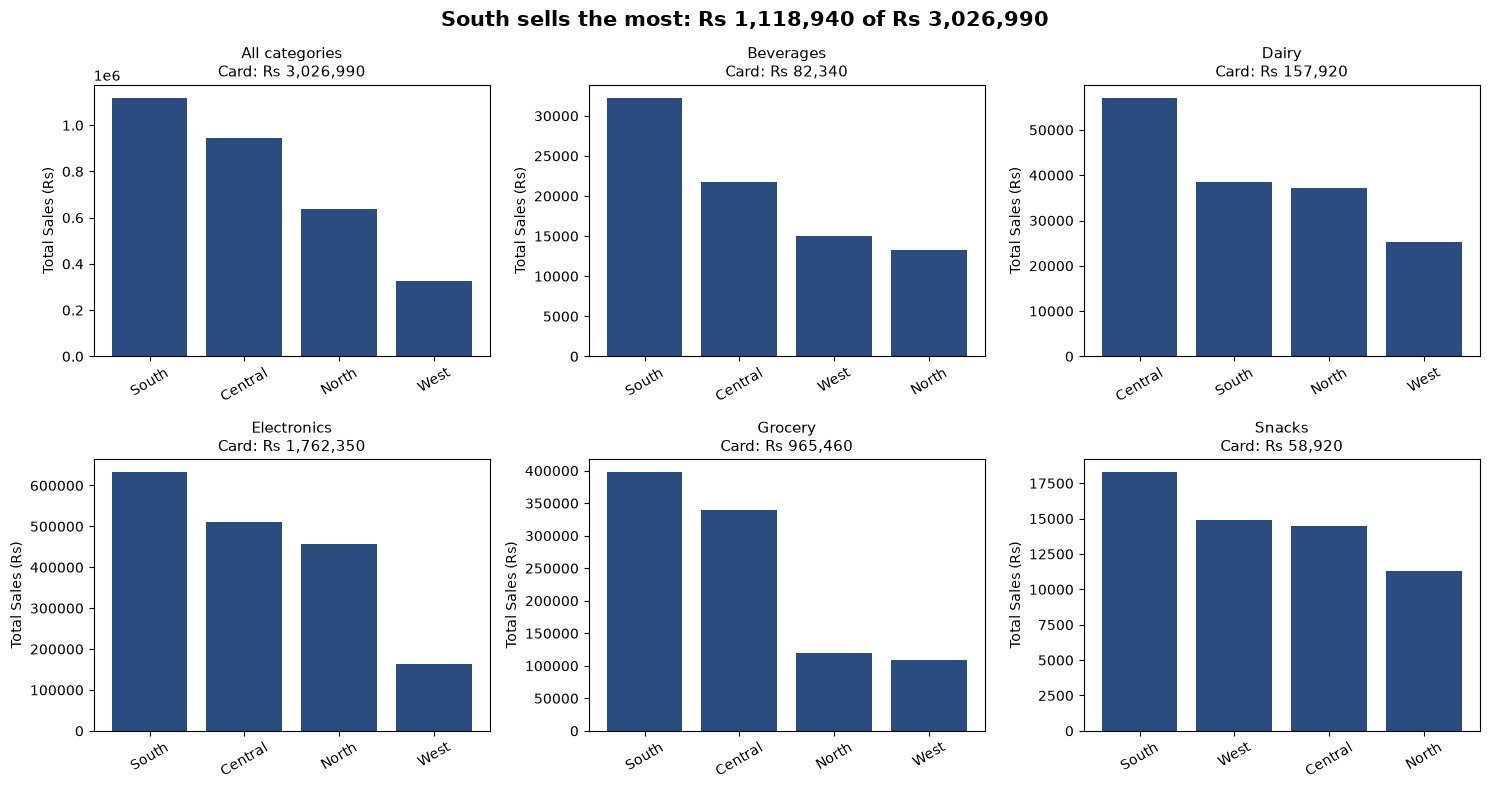

RegionName
South      1118940
Central     943410
North       637340
West        327300
Name: SalesAmount, dtype: int64


In [6]:
def region_totals(df): 
    return df.groupby("RegionName").SalesAmount.sum().reindex(sorted(reg.RegionName)).sort_values(ascending=False)

cats = sorted(data.Category.unique())
selections = [None] + cats
fig, axes = plt.subplots(2, (len(selections)+1)//2, figsize=(5*((len(selections)+1)//2), 8), squeeze=False)
for ax, cat in zip(axes.ravel(), selections):
    view = data if cat is None else data[data.Category == cat]      # filter = a view, original untouched
    t = region_totals(view)
    ax.bar(t.index, t.values, color="#2b4c7e")
    ax.set_title(f"{'All categories' if cat is None else cat}\nCard: Rs {view.SalesAmount.sum():,.0f}", fontsize=11)
    ax.tick_params(axis="x", rotation=30); ax.set_ylabel("Total Sales (Rs)")
for ax in axes.ravel()[len(selections):]: ax.axis("off")
top = region_totals(data)
fig.suptitle(f"{top.index[0]} sells the most: Rs {top.iloc[0]:,.0f} of Rs {data.SalesAmount.sum():,.0f}", fontsize=15, fontweight="bold")
fig.tight_layout(); fig.savefig("task5_report.png", dpi=150, bbox_inches="tight"); plt.show()
print(top)

## Validate — results

In [7]:
total = sales.SalesAmount.sum()
cat_sum = sum(data[data.Category == c].SalesAmount.sum() for c in cats)
checks = {
 "1 Card (no filter) == sum of all 480 rows": f"{data.SalesAmount.sum():,.2f} vs {total:,.2f} -> {'PASS' if abs(data.SalesAmount.sum()-total)<0.01 and len(data)==480 else 'FAIL'}",
 "2 Categories one by one add back to total": f"{cat_sum:,.2f} -> {'PASS' if abs(cat_sum-total)<0.01 else 'FAIL'}",
 "3 Source file unchanged after slicing": "PASS" if sha(F) == hash_before else "FAIL",
 "4 No errors / blanks in visuals": f"nulls in joined data = {int(data[['ProductName','Category','RegionName','SalesAmount']].isna().sum().sum())} -> {'PASS' if data[['ProductName','Category','RegionName','SalesAmount']].notna().all().all() else 'FAIL'}",
}
pd.Series(checks).to_frame("Result")

,Result
1 Card (no filter) == sum of all 480 rows,"3,026,990.00 vs 3,026,990.00 -> PASS"
2 Categories one by one add back to total,"3,026,990.00 -> PASS"
3 Source file unchanged after slicing,PASS
4 No errors / blanks in visuals,nulls in joined data = 0 -> PASS


## UnitPrice — which to use?

In [8]:
chk = sales.merge(prod[["ProductID","UnitPrice"]], on="ProductID", suffixes=("", "_Products"))
print("SalesAmount == Qty x Sales.UnitPrice    :", f"{((chk.Quantity*chk.UnitPrice - chk.SalesAmount).abs()<0.01).mean():.0%}")
print("SalesAmount == Qty x Products.UnitPrice :", f"{((chk.Quantity*chk.UnitPrice_Products - chk.SalesAmount).abs()<0.01).mean():.0%}")
print("Rows where the two prices differ:", (chk.UnitPrice != chk.UnitPrice_Products).sum())

SalesAmount == Qty x Sales.UnitPrice    : 100%
SalesAmount == Qty x Products.UnitPrice : 100%
Rows where the two prices differ: 0


**Decision:** use `Sales.UnitPrice` — the price charged at the time of the sale. `Products.UnitPrice` is the current list price and can change, so using it would restate past sales; it is left out of the report. Totals use `SalesAmount` directly. Assumption: `Sales.UnitPrice` is the sale-time price (the percentages above show which column reproduces `SalesAmount`).

## The question: why was "which region sells most?" answered in a minute?
Per Task 2, this is an **OLAP** question: it aggregates 480 rows by region over six months, and it ran on a **separate read-only copy** of the data loaded into memory, not on the live database the counters write to. Nobody was blocked because it competed with no transaction.

At 6 pm on a Friday against the live branch database, the same scan and aggregation would run on the OLTP server at peak billing. It would use I/O and CPU, evict the cached pages billing needs and hold locks, so each bill would slow and counters would queue — the same failure as the CEO's report in Task 2.